In [30]:
import json
import pandas as pd
import os
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

In [3]:
X_train= pd.read_csv("/kaggle/input/datasets/prahazra/employee-attrition-processed/X_train_final.csv")
x_test= pd.read_csv("/kaggle/input/datasets/prahazra/employee-attrition-processed/X_test_final.csv")
x_test.drop(columns=['Unnamed: 0'], inplace= True)

Y_train= pd.read_csv("/kaggle/input/datasets/prahazra/employee-attrition-processed/y_train_final.csv").squeeze()
y_test= pd.read_csv("/kaggle/input/datasets/prahazra/employee-attrition-processed/y_test_final.csv")
y_test.drop(columns=['Unnamed: 0'], inplace= True)
y_test.squeeze()

0      0
1      0
2      1
3      1
4      0
      ..
289    0
290    0
291    0
292    0
293    0
Name: Attrition, Length: 294, dtype: int64

In [4]:
def load_params(file_path):
    with open(file_path, "r") as f:
        params_dict = json.load(f)
    print(f"Successfully loaded from: {file_path}")
    return params_dict

LR_params= load_params("/kaggle/input/notebooks/prahazra/model-optimization-ea/LR_params.json")
RF_params= load_params("/kaggle/input/notebooks/prahazra/model-optimization-ea/RF_params.json")
GB_params= load_params("/kaggle/input/notebooks/prahazra/model-optimization-ea/GB_params.json")
XGB_params= load_params("/kaggle/input/notebooks/prahazra/model-optimization-ea/XGB_params.json")

Successfully loaded from: /kaggle/input/notebooks/prahazra/model-optimization-ea/LR_params.json
Successfully loaded from: /kaggle/input/notebooks/prahazra/model-optimization-ea/RF_params.json
Successfully loaded from: /kaggle/input/notebooks/prahazra/model-optimization-ea/GB_params.json
Successfully loaded from: /kaggle/input/notebooks/prahazra/model-optimization-ea/XGB_params.json


In [21]:
LR_params

{'penalty': 'l2',
 'C': 9.138176364000486,
 'tol': 0.0002905739778222947,
 'solver': 'lbfgs',
 'max_iter': 81}

In [22]:
LR_classifier= LogisticRegression(**LR_params, random_state = 0)
LR_classifier.fit(X_train, Y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(C=9.138176364000486, max_iter=81, random_state=0,
                   tol=0.0002905739778222947)

In [19]:
RF_params['max_features']= RF_params.pop('max_features_option')
RF_params

{'n_estimators': 273,
 'criterion': 'log_loss',
 'max_depth': 9,
 'min_samples_split': 13,
 'bootstrap': False,
 'class_weight': None,
 'max_features': 'log2'}

In [23]:
RF_classifier= RandomForestClassifier(**RF_params, random_state=0)
RF_classifier.fit(X_train, Y_train)

RandomForestClassifier(bootstrap=False, criterion='log_loss', max_depth=9,
                       max_features='log2', min_samples_split=13,
                       n_estimators=273, random_state=0)

In [15]:
GB_params['max_features']= GB_params.pop('max_features_option')
GB_params

{'loss': 'exponential',
 'learning_rate': 0.06632642685269954,
 'n_estimators': 164,
 'criterion': 'friedman_mse',
 'min_samples_split': 6,
 'min_impurity_decrease': 0.0007913244532219677,
 'max_depth': 10,
 'max_features': 'log2'}

In [24]:
GB_classifier= GradientBoostingClassifier(**GB_params, random_state = 0)
GB_classifier.fit(X_train, Y_train)

GradientBoostingClassifier(learning_rate=0.06632642685269954,
                           loss='exponential', max_depth=10,
                           max_features='log2',
                           min_impurity_decrease=0.0007913244532219677,
                           min_samples_split=6, n_estimators=164,
                           random_state=0)

In [25]:
XGB_params

{'n_estimators': 463,
 'max_depth': 14,
 'grow_policy': 'lossguide',
 'learning_rate': 0.0823410572431586,
 'booster': 'gbtree',
 'gamma': 0.07161494055944798,
 'min_child_weight': 1}

In [27]:
XGB_classifier= XGBClassifier(**XGB_params)
XGB_classifier.fit(X_train, Y_train)

XGBClassifier(base_score=None, booster='gbtree', callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=0.07161494055944798,
              grow_policy='lossguide', importance_type=None,
              interaction_constraints=None, learning_rate=0.0823410572431586,
              max_bin=None, max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=14, max_leaves=None,
              min_child_weight=1, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=463, n_jobs=None,
              num_parallel_tree=None, ...)

In [35]:
LR_pred= LR_classifier.predict(x_test)
RF_pred= RF_classifier.predict(x_test)
GB_pred= GB_classifier.predict(x_test)
XGB_pred= XGB_classifier.predict(x_test)

predictions_map = {
    'Logistic Regression': LR_pred,
    'Random Forest': RF_pred,
    'Gradient Boosting': GB_pred,
    'XGBoost': XGB_pred
}

performance_data = []

for model_name, y_pred in predictions_map.items():
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    
    performance_data.append({
        'Model': model_name,
        'Accuracy': f"{accuracy * 100:.2f}%",
        'Precision': f"{precision * 100:.2f}%",
        'Recall': f"{recall * 100:.2f}%",
        'F1-Score': f"{f1 * 100:.2f}%"
    })

performance_df = pd.DataFrame(performance_data)
print(performance_df)

                 Model Accuracy Precision  Recall F1-Score
0  Logistic Regression   75.85%    36.05%  65.96%   46.62%
1        Random Forest   85.03%    63.64%  14.89%   24.14%
2    Gradient Boosting   85.71%    85.71%  12.77%   22.22%
3              XGBoost   86.39%    81.82%  19.15%   31.03%


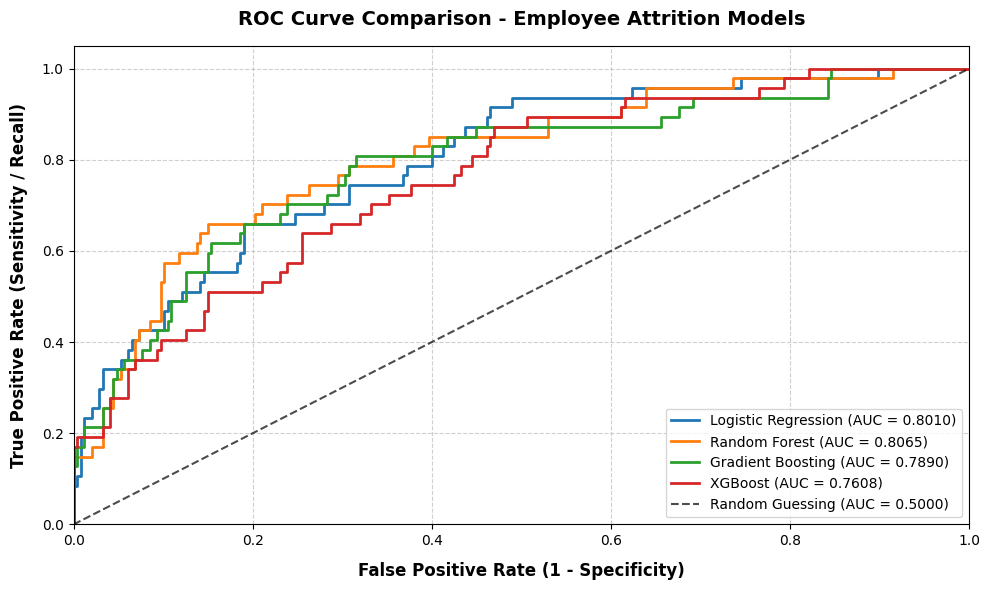

In [37]:


# 1. Map your models into a clean dictionary
# Ensure your model variables match these names exactly in your environment
models = {
    'Logistic Regression': LR_classifier,
    'Random Forest': RF_classifier,
    'Gradient Boosting': GB_classifier,
    'XGBoost': XGB_classifier
}

plt.figure(figsize=(10, 6))

for name, model in models.items():
    y_probs = model.predict_proba(x_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_probs)
    auc_score = roc_auc_score(y_test, y_probs)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc_score:.4f})', linewidth=2)

plt.plot([0, 1], [0, 1], 'k--', label='Random Guessing (AUC = 0.5000)', alpha=0.7)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)', fontsize=12, fontweight='bold', labelpad=10)
plt.ylabel('True Positive Rate (Sensitivity / Recall)', fontsize=12, fontweight='bold', labelpad=10)
plt.title('ROC Curve Comparison - Employee Attrition Models', fontsize=14, fontweight='bold', pad=15)
plt.legend(loc="lower right", fontsize=10, frameon=True)
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()
